In [1]:
import os
import glob
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import sys
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import ttest_rel, ttest_1samp, wilcoxon

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))
blues = sns.color_palette("Blues", 5)[1:4]      
oranges = sns.color_palette("Oranges", 5)[1:4]

# Global variables
media = ["GluT", "Glu"]
media_titles = ["GluT", "Glu"]
plots_prefix = "glu"
nmedia = 2
nreplicates=3
chan_r = 0
chan_g = 1
thresholds_to_try = np.linspace(0,1,101)
chosen_thr = 80
ring_width = 1

# Partener subset
partner_subset = ['G3','GN4','Ct','AlFa','G4','PsAe','PsFu','S1']
partner_subset.sort()

# Setup folders 
proj_dir = pathlib.Path("/home/alessia/Documents/PhD/Colony-project")
raw_data_dir = proj_dir / 'raw_data' / '20260615_D5_GLUCOSE'
proc_data_dir = proj_dir / 'processed_data' / '20260615_D5_GLUCOSE'
cfu_dir = proj_dir / 'cfu_counts'
if ring_width == 5:
   plot_dir = proj_dir / 'figures' / 'GLUCOSE'
elif ring_width == 1:
   plot_dir = proj_dir / 'figures_ring_1' / 'GLUCOSE'
if not os.path.exists(plot_dir):
   os.makedirs(plot_dir)
   
# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *
from _image_analysis_functions import *

# Functions
def significance_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
    
def add_sig_bar(ax, x1, x2, y, text,h = 0.01):
    ax.plot([x1,x2], [y, y], color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=14)

NOTE: Remove PsAe because it dies. Remove G3 because no sectors.

In [2]:
remove_psae = True
remove_g3 = True

In [3]:
# CFU counts
cfu_df = pd.read_csv(cfu_dir / 'raw_data/20260616_GLUCOSE.csv')
# remove PsAe from the data
if remove_psae:
    cfu_df = cfu_df[(cfu_df["strain"]!="PsAe")&(cfu_df["partner"] != "PsAe")]
if remove_g3:
    cfu_df = cfu_df[(cfu_df["strain"]!="G3")&(cfu_df["partner"] != "G3")]
cfu_df.head()

,strain,condition,culture,partner,replicate,CFUs,comments,day,count,dilution
0,Oa,NaN,mono,NaN,1,40000.0,NaN,0,40.0,4.0
2,GN4,NaN,mono,NaN,1,110000.0,NaN,0,11.0,5.0
3,Ct,NaN,mono,NaN,1,25000.0,NaN,0,25.0,4.0
4,G4,NaN,mono,NaN,1,100000.0,NaN,0,10.0,5.0
5,AlFa,NaN,mono,NaN,1,30000.0,NaN,0,30.0,4.0


In [4]:
# partner identities
strains = pd.unique(cfu_df["strain"])
nstrains = len(strains)
npartners = len(strains) - 1
partners = [s for s in strains if s != "Oa"]
partners.sort()
print(partners)

['AlFa', 'Ct', 'G4', 'GN4', 'PsFu', 'S1']


In [5]:
# Load image analysis data
if ring_width == 5:
    data = pd.read_csv('glu_image_analysis.csv')
elif ring_width == 1:
    data = pd.read_csv('glu_image_analysis_ring_1.csv')
# remove PsAe from the data
if remove_psae:
    data = data[(data["partner"]!="PsAe")]
if remove_g3:
    data = data[(data["partner"]!="G3")]
data.head()

,partner,media,replicate,intermixing_indices,rings,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency
0,AlFa,GluT,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.000000,1342.704965,2.224823,0.999335
1,AlFa,GluT,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.000000,1971.245625,7.548125,0.996256
2,AlFa,GluT,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.000000,1655.905405,3.094595,0.999560
3,AlFa,Glu,1,"[0.02753123602189284, 0.025000522730408987, 0....","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.322796,213.337871,5.387881,0.945646
4,AlFa,Glu,2,"[0.015562426869559212, 0.014237472904656188, 0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.232025,116.061214,6.404579,0.900657


In [6]:
# Relative sector size
data["rel_oa_ss"] = (data["sector_size_Oa"] / (data["sector_size_Oa"] + data["sector_size_partner"]))*(1/data["oa_frequency"])
data["rel_p_ss"] = (data["sector_size_partner"] / (data["sector_size_Oa"] + data["sector_size_partner"]))*(1/(1-data["oa_frequency"]))

In [7]:
# Cange in mixing from FAT to FA
data_pivot = data.pivot(index=["partner","replicate"], columns="media", values=["mean_intermixing","rel_oa_ss","rel_p_ss","sector_size_Oa","sector_size_partner"]).reset_index()
data_pivot.head()

partner replicate mean_intermixing      rel_oa_ss            rel_p_ss  \
media                                Glu GluT       Glu      GluT       Glu   
0        AlFa         1         0.322796  0.0  1.031429  0.999010  0.453197   
1        AlFa         2         0.232025  0.0  1.052236  0.999929  0.526426   
2        AlFa         3         0.187818  0.0  1.054188  0.998574  0.614538   
3          Ct         1         0.070976  0.0  1.068990  0.999930  0.607138   
4          Ct         2         0.199218  0.0  1.003223  0.999484  0.958528   

                sector_size_Oa              sector_size_partner            
media      GluT            Glu         GluT                 Glu      GluT  
0      2.487653     213.337871  1342.704965            5.387881  2.224823  
1      1.018955     116.061214  1971.245625            6.404579  7.548125  
2      4.236570      90.624388  1655.905405            7.426695  3.094595  
3      1.039385     107.415562  2276.060847           10.713341  4.207804  
4      5.515944     105.620821   556.791139            7.842398  0.351266

In [8]:
data_pivot["delta_mean_intermixing"] = data_pivot["mean_intermixing"][media[1]] - data_pivot["mean_intermixing"][media[0]]
data_pivot["delta_rel_oa_ss"] = data_pivot["rel_oa_ss"][media[1]] - data_pivot["rel_oa_ss"][media[0]]
data_pivot["delta_rel_p_ss"] = data_pivot["rel_p_ss"][media[1]] - data_pivot["rel_p_ss"][media[0]]
data_pivot["delta_sector_size_Oa"] = data_pivot["sector_size_Oa"][media[1]] - data_pivot["sector_size_Oa"][media[0]]
data_pivot["delta_sector_size_partner"] = data_pivot["sector_size_partner"][media[1]] - data_pivot["sector_size_partner"][media[0]]
data_pivot.head()

partner replicate mean_intermixing      rel_oa_ss            rel_p_ss  \
media                                Glu GluT       Glu      GluT       Glu   
0        AlFa         1         0.322796  0.0  1.031429  0.999010  0.453197   
1        AlFa         2         0.232025  0.0  1.052236  0.999929  0.526426   
2        AlFa         3         0.187818  0.0  1.054188  0.998574  0.614538   
3          Ct         1         0.070976  0.0  1.068990  0.999930  0.607138   
4          Ct         2         0.199218  0.0  1.003223  0.999484  0.958528   

                sector_size_Oa              sector_size_partner            \
media      GluT            Glu         GluT                 Glu      GluT   
0      2.487653     213.337871  1342.704965            5.387881  2.224823   
1      1.018955     116.061214  1971.245625            6.404579  7.548125   
2      4.236570      90.624388  1655.905405            7.426695  3.094595   
3      1.039385     107.415562  2276.060847           10.713341  4.207804   
4      5.515944     105.620821   556.791139            7.842398  0.351266   

      delta_mean_intermixing delta_rel_oa_ss delta_rel_p_ss  \
media                                                         
0                   0.322796        0.032419      -2.034456   
1                   0.232025        0.052307      -0.492528   
2                   0.187818        0.055613      -3.622032   
3                   0.070976        0.069060      -0.432247   
4                   0.199218        0.003739      -4.557416   

      delta_sector_size_Oa delta_sector_size_partner  
media                                                 
0             -1129.367093                  3.163059  
1             -1855.184411                 -1.143546  
2             -1565.281018                  4.332101  
3             -2168.645284                  6.505537  
4              -451.170319                  7.491132

## Interactions plot

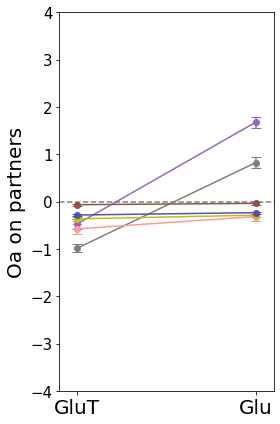

In [9]:
# Oa on P
fig, ax = plt.subplots(figsize=(4,6))
for partner in partners:

    # Oa on Partners
    mean_oa_on_p_fat = np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fat = np.nanstd([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_oa_on_p_fa = np.mean([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_oa_on_p_fa = np.nanstd([get_oa_on_p(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_oa_on_p_fa) | np.isnan(std_oa_on_p_fa) | np.isnan(mean_oa_on_p_fat) | np.isnan(std_oa_on_p_fat):
        print(f"Mean and std Oa on {partner} in FA: {mean_oa_on_p_fa}, {std_oa_on_p_fa}")
    else:
        ax.errorbar([0, 1],[mean_oa_on_p_fat, mean_oa_on_p_fa],yerr=[std_oa_on_p_fat, std_oa_on_p_fa],marker="o",linestyle="-",capsize=5,label=partner,color=color_dict[partner],ecolor=color_dict[partner])


ax.set_ylabel("Oa on partners")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)
#ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_oa_on_p.pdf", dpi=600)
plt.show()

In [10]:
mean_oa_on_p_fat = np.mean([np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
std_oa_on_p_fat = np.std([np.mean([get_oa_on_p(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
print(f"Mean Oa on partners in FAT: {mean_oa_on_p_fat:.3f} ± {std_oa_on_p_fat:.3f}")

mean_p_on_oa_fat = np.mean([np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
std_p_on_oa_fat = np.std([np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)]) for partner in partners])
print(f"Mean P on Oa in FAT: {mean_p_on_oa_fat:.3f} ± {std_p_on_oa_fat:.3f}")


Mean Oa on partners in FAT: -0.458 ± 0.284
Mean P on Oa in FAT: -0.582 ± 0.368


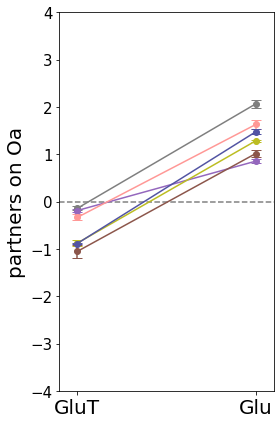

In [11]:
# P on Oa 
fig, ax = plt.subplots(figsize=(4,6))
for partner in partners:

    # Oa on Partners
    mean_p_on_oa_fat = np.mean([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    std_p_on_oa_fat = np.nanstd([get_p_on_oa(cfu_df, media[0], partner, rep) for rep in range(1, nreplicates + 1)])
    mean_p_on_oa_fa = np.mean([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    std_p_on_oa_fa = np.nanstd([get_p_on_oa(cfu_df, media[1], partner, rep) for rep in range(1, nreplicates + 1)])
    if np.isnan(mean_p_on_oa_fa) | np.isnan(std_p_on_oa_fa) | np.isnan(mean_p_on_oa_fat) | np.isnan(std_p_on_oa_fat):
        print(f"Mean and std {partner} on Oa in FA: {mean_p_on_oa_fa}, {std_p_on_oa_fa}")
    else:
        ax.errorbar([0, 1],[mean_p_on_oa_fat, mean_p_on_oa_fa],yerr=[std_p_on_oa_fat, std_p_on_oa_fa],marker="o",linestyle="-",capsize=5,label=partner,color=color_dict[partner],ecolor=color_dict[partner])


ax.set_ylabel("partners on Oa")
ax.axhline(0, color="gray", linestyle="dashed")
ax.set_ylim(-4,4)
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlim(-0.1, 1.1)
# ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_p_on_oa.pdf", dpi=600)
plt.show()

## Effect of changing medium on mixing and sector sizes

Median intermixing in GluT: 0.050401346602983614
Median intermixing in Glu: 0.1369532988074174
Wilcoxon signed-ranktest: stat=0.0, p-value=0.015625


/tmp/ipykernel_26360/323675398.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/323675398.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/323675398.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/323675398.py:16: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layou

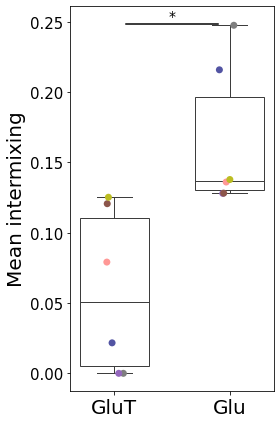

In [12]:
# Intermixing distributions
mean_intermixing = data.groupby(["partner", "media"])["mean_intermixing"].agg(["mean", "std"]).reset_index()
print(f"Median intermixing in {media[0]}: {mean_intermixing[mean_intermixing['media'] == media[0]]['mean'].median()}")
print(f"Median intermixing in {media[1]}: {mean_intermixing[mean_intermixing['media'] == media[1]]['mean'].median()}")
stat, p_value = wilcoxon(mean_intermixing[mean_intermixing["media"] == media[0]]["mean"], mean_intermixing[mean_intermixing["media"] == media[1]]["mean"],alternative="less")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_intermixing, ax=ax, x="media", y="mean", order=media, hue="partner", palette=color_dict, size=7)
sns.boxplot(data=mean_intermixing, ax=ax, x="media", y="mean", order=media,width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.ylabel("Mean intermixing")
plt.xticks([0, 1], media_titles)
plt.legend([],[], frameon=False)
plt.xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_intermixing["mean"].max() + 0.001, significance_stars(p_value), h = 0.0005)
# ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_intermixing.pdf", dpi=600)

Wilcoxon signed-rank test: stat=21.0, p-value=0.015625


/tmp/ipykernel_26360/1805134418.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/1805134418.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/1805134418.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/1805134418.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

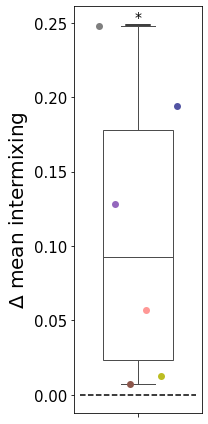

In [13]:
# Mean delta intermixing
mean_delta_intermixing = data_pivot.groupby("partner")["delta_mean_intermixing"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_intermixing["mean"] - 0, alternative="greater")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_intermixing, ax=ax, y="mean", hue="partner",palette=color_dict, dodge=True, size=7)
sns.boxplot(data=mean_delta_intermixing, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_intermixing["mean"].max() + 0.001, significance_stars(p), h = 0.0005)
ax.set_ylabel(r"$\Delta$ mean intermixing")
ax.legend([],[], frameon=False)
ax.set_xlabel("")
# ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_intermixing.pdf", dpi=600)

Median Oa sector size in GluT: 95.02753354848528
Median Oa sector size in Glu: 51.37240595400645
Wilcoxon signed-ranktest: stat=19.0, p-value=0.046875


/tmp/ipykernel_26360/2543514322.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/2543514322.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/2543514322.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/2543514322.py:17: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

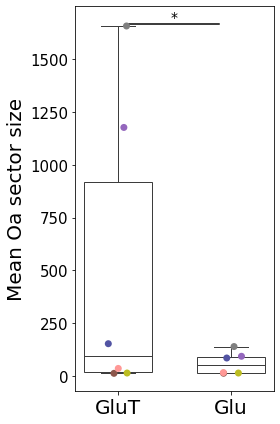

In [14]:
# Oa sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
print(f"Median Oa sector size in {media[0]}: {mean_sector_size[mean_sector_size['media'] == media[0]]['mean'].median()}")
print(f"Median Oa sector size in {media[1]}: {mean_sector_size[mean_sector_size['media'] == media[1]]['mean'].median()}")
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"],alternative="greater")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", order=media, hue="partner",color="gray", size=7, palette=color_dict)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", order=media, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean Oa sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
ax.set_xlabel("")
plt.legend([],[], frameon=False)
# ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left")
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 10, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_oa_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=2.0, p-value=0.046875


/tmp/ipykernel_26360/2298887205.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)
/tmp/ipykernel_26360/2298887205.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)
/tmp/ipykernel_26360/2298887205.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)
/tmp/ipykernel_26360/2298887205.py:15: MatplotlibDeprecationWarning: Support for passing numbers thr

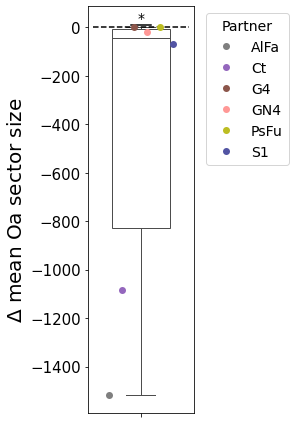

In [15]:
# Mean delta Oa sector size
mean_delta_oa_ss = data_pivot.groupby("partner")["delta_sector_size_Oa"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(4.3,6))
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_oa_ss, ax=ax, y="mean", hue="partner", palette=color_dict, dodge=True, size=7)
sns.boxplot(data=mean_delta_oa_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r"$\Delta$ mean Oa sector size")
ax.set_xlabel("")
ax.legend([],[], frameon=False)
ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left",fontsize=14,title_fontsize=14)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_oa_ss.pdf", dpi=600)

Wilcoxon signed-ranktest: stat=8.0, p-value=0.6875


/tmp/ipykernel_26360/3951722999.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/3951722999.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/3951722999.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/3951722999.py:15: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_l

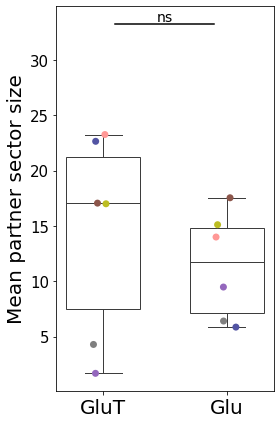

In [16]:
# Partner sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["sector_size_partner"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"])
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax, x="media", y="mean", hue="partner", order=media, palette=color_dict, size=7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", order=media, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean partner sector size")
ax.set_xticks([0, 1])
ax.set_xticklabels(media_titles)
plt.legend([],[], frameon=False)
# ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 10, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_partner_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=8.0, p-value=0.6875


/tmp/ipykernel_26360/107925135.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/107925135.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/107925135.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layout()
/tmp/ipykernel_26360/107925135.py:14: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.tight_layou

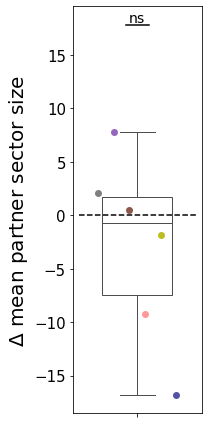

In [17]:
# Mean delta partner sector size
mean_delta_p_ss = data_pivot.groupby("partner")["delta_sector_size_partner"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(3,6))
stat, p = wilcoxon(mean_delta_p_ss["mean"] - 0)
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
sns.stripplot(data=mean_delta_p_ss, ax=ax, y="mean", hue="partner", palette=color_dict, dodge=True, size=7)
sns.boxplot(data=mean_delta_p_ss, ax=ax, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
add_sig_bar(ax, -0.1, 0.1, mean_delta_p_ss["mean"].max() + 10, significance_stars(p), h = 0.0005)
ax.set_ylabel(r"$\Delta$ mean partner sector size")
ax.legend([],[], frameon=False)
# ax.legend(title="Partner", bbox_to_anchor=(1.05, 1), loc="upper left",fontsize=14,title_fontsize=14)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_p_ss.pdf", dpi=600)

Wilcoxon signed-ranktest: stat=6.0, p-value=0.4375


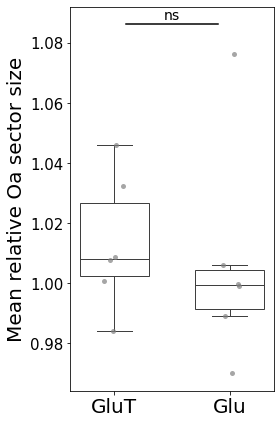

In [18]:
# Relative sector size distributions
mean_sector_size = data.groupby(["partner", "media"])["rel_oa_ss"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"])
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_sector_size, ax=ax,x="media", y="mean", color="gray", size=5, alpha=0.7)
sns.boxplot(data=mean_sector_size, ax=ax, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
ax.set_ylabel("Mean relative Oa sector size")
ax.set_xticks([0, 1])
ax.set_xlabel("")
ax.set_xticklabels(media_titles)
ax.legend([],[], frameon=False)
add_sig_bar(ax, 0.1, 0.9, mean_sector_size["mean"].max() + 0.01, significance_stars(p_value), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_relative_oa_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-ranktest: stat=4.0, p-value=0.21875


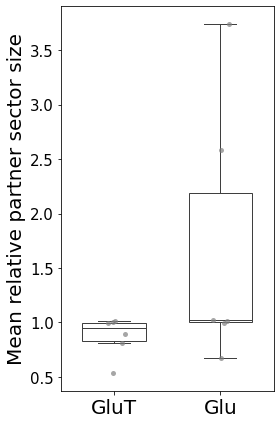

In [19]:
mean_sector_size = data.groupby(["partner", "media"])["rel_p_ss"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_sector_size[mean_sector_size["media"] == media[0]]["mean"], mean_sector_size[mean_sector_size["media"] == media[1]]["mean"])
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
plt.figure(figsize=(4,6))
sns.stripplot(data=mean_sector_size, x="media", y="mean", color="gray",size=5, alpha=0.7)
sns.boxplot(data=mean_sector_size, x="media", y="mean", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.ylabel("Mean relative partner sector size")
plt.xlabel("Media")
plt.xticks([0, 1], media_titles)
plt.legend([],[], frameon=False)
plt.xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_relative_partner_ss.pdf", dpi=600)
plt.show()

Wilcoxon signed-rank test: stat=15.0, p-value=0.84375


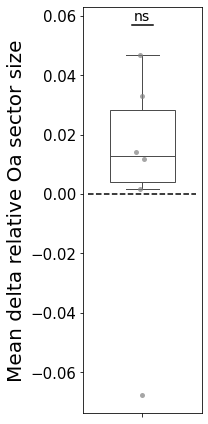

In [20]:
# Mean delta Oa sector size
mean_delta_oa_ss = data_pivot.groupby("partner")["delta_rel_oa_ss"].agg(["mean", "std"]).reset_index()
stat, p = wilcoxon(mean_delta_oa_ss["mean"] - 0, alternative="less")
print(f"Wilcoxon signed-rank test: stat={stat}, p-value={p}")
plt.figure(figsize=(3,6))
sns.stripplot(data=mean_delta_oa_ss, y="mean", color="gray", dodge=True, size=5, alpha=0.7)
sns.boxplot(data=mean_delta_oa_ss, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
plt.ylabel("Mean delta relative Oa sector size")
plt.xlabel("Partner")
plt.legend([],[], frameon=False)
plt.xlabel("")
add_sig_bar(plt.gca(), -0.1, 0.1, mean_delta_oa_ss["mean"].max() + 0.01, significance_stars(p), h = 0.0005)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_rel_oa_ss.pdf", dpi=600)

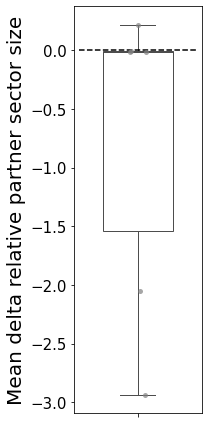

In [21]:
# Mean delta partner sector size
mean_delta_p_ss = data_pivot.groupby("partner")["delta_rel_p_ss"].agg(["mean", "std"]).reset_index()
plt.figure(figsize=(3,6))
sns.stripplot(data=mean_delta_p_ss, y="mean", color="gray", dodge=True, size=5, alpha=0.7)
sns.boxplot(data=mean_delta_p_ss, y="mean", color="gray", width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.hlines(0, -0.5, 0.5, color="black", linestyle="dashed")
plt.ylabel("Mean delta relative partner sector size")
plt.xlabel("Partner")
plt.legend([],[], frameon=False)
plt.xlabel("")
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_delta_rel_p_ss.pdf", dpi=600)
plt.show()